In [54]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

In [55]:
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > 1e-6:
        raise RuntimeError(
            f"Self-consistency violated: max |Δ| = {max_err:e}"
        )

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > check_tol:
        mag = np.abs(eigvals)
        print("Sorted |eigvals|:", np.sort(mag))
        raise RuntimeError(
            fr"Self-consistency violated: max |Δ| = {max_err}"
        )

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL
    return G_RL, Sigma_R, Sigma_L

def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导。
    内部动态将 2x2 基础矩阵组装为 4x4 的超胞(Supercell)矩阵进行计算。
    """
    G_total_at_E = 0.0  
    
    # 定义 2x2 的全零矩阵，用于充当超胞矩阵里的空白填补块
    zero_2 = np.zeros((2, 2), dtype=complex)
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        
        # ================= 1. 从字典中提取 2x2 基础矩阵 =================
        H_q_1 = mats["H_q_list"][0]  # 交替列表的第1个中心在位
        H_q_2 = mats["H_q_list"][1]  # 交替列表的第2个中心在位
        T_21_base = mats["T_21"]     # 基础跃迁
        
        H_l_1 = mats["H_l_1"]
        H_l_2 = mats["H_l_2"]
        T_l_base = mats["T_l"]
        
        H_r_1 = mats["H_r_1"]
        H_r_2 = mats["H_r_2"]
        T_r_base = mats["T_r"]
        
        T_LD_base = mats["T_LD"]
        T_RD_base = mats["T_RD"]
        
        # ================= 2. 严格按照指定位置，动态组装 4x4 超胞矩阵 =================
        
        # 中心区超胞在位矩阵
        H_super = np.block([
            [H_q_1,              T_21_base],
            [T_21_base.conj().T, H_q_2]
        ])
        # 组装含有 xshumu 个 H_super 块的中心区列表
        H_q_list_super = [H_super for _ in range(xshumu)]

        # 中心区超胞间基础跃迁矩阵
        T_21_super = np.block([
            [zero_2,    zero_2],
            [T_21_base, zero_2]
        ])
        
        # 左导线超胞在位矩阵
        H_l_super = np.block([
            [H_l_1,              T_l_base],
            [T_l_base.conj().T,  H_l_2]
        ])
        
        # 左导线超胞间跃迁矩阵
        T_l_super = np.block([
            [zero_2, T_l_base],
            [zero_2, zero_2]
        ])
        
        # 右导线超胞在位矩阵
        H_r_super = np.block([
            [H_r_1,              T_r_base],
            [T_r_base.conj().T,  H_r_2]  # 已修正原提示词中的语法小错 T_r_conj().T -> T_r.conj().T
        ])
        
        # 右导线超胞间跃迁矩阵
        T_r_super = np.block([
            [zero_2,  zero_2],
            [T_r_base, zero_2]
        ])
        
        # 左耦合超胞间跃迁矩阵
        T_LD_super = np.block([
            [zero_2,    zero_2],
            [T_LD_base, zero_2]
        ])
        
        # 右耦合超胞间跃迁矩阵
        T_RD_super = np.block([
            [zero_2, T_RD_base],
            [zero_2, zero_2]
        ])
        

        # ================= 3. 将组装好的 4x4 矩阵喂给格林函数求解器 =================
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(
            H_q_list=H_q_list_super,  # 传入 4x4 块组成的列表
            H_l=H_l_super,            # 4x4
            H_r=H_r_super,            # 4x4
            T_21=T_21_super,          # 4x4
            T_LD=T_LD_super,          # 4x4
            T_l=T_l_super,            # 4x4
            T_RD=T_RD_super,          # 4x4
            T_r=T_r_super,            # 4x4
            xshumu=xshumu, 
            E=E_val,
            eta=eta
        )
        
        # ================= 4. Landauer-Büttiker 公式计算透射率 =================
        # 计算左右电极的自能展宽矩阵 (\Gamma = i * (\Sigma - \Sigma^\dagger))
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        # Trace(\Gamma_R * G * \Gamma_L * G^\dagger)
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E
    


In [56]:
def build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, a, xshumu):
    """
    根据锯齿形纳米管的结构参数，构建所有波矢 ky 通道下的哈密顿量与跃迁矩阵字典。
    """
    max_duihaoshu = m
    matrix_dict = {}

    for duihaoshu in range(1, max_duihaoshu + 1):  
        # 计算当前通道的 ky
        ky = np.pi * (duihaoshu + 0.5) / (a * m)
        
        # --- 中心散射区 (Quantum Dot/Scattering Region) ---
        H_q_1 = H_onstie_1(mu_q, t, a, ky)
        H_q_2 = H_onstie_2(mu_q, t, a, ky)
        T_21 = H_hop(t)

        # 交替添加 H_q_1 和 H_q_2，总长度为 xshumu
        H_q_list = []
        for i in range(xshumu):
            if i % 2 == 0:
                H_q_list.append(H_q_1)
            else:
                H_q_list.append(H_q_2)
        
        # --- 左侧导线 (Left Lead) ---
        H_l_1 = H_onstie_1(mu_l, t, a, ky)
        H_l_2 = H_onstie_2(mu_l, t, a, ky)
        T_l = H_hop(t).conj().T 
        
        # --- 右侧导线 (Right Lead) ---
        H_r_1 = H_onstie_1(mu_r, t, a, ky)
        H_r_2 = H_onstie_2(mu_r, t, a, ky)
        T_r = H_hop(t)
        
        # --- 导线与中心区的耦合 ---
        T_LD = H_hop(t) 
        T_RD = H_hop(t).conj().T 

        # 打包存入字典
        matrix_dict[duihaoshu] = {
            "H_q_list": H_q_list,      # 长度为 xshumu 的列表: [H_q_1, H_q_2, H_q_1...]
            "T_21": T_21,
            "H_l_1": H_l_1,            # 存入具体的左右电极分量子晶格
            "H_l_2": H_l_2,
            "T_l": T_l,
            "H_r_1": H_r_1,
            "H_r_2": H_r_2,
            "T_r": T_r,
            "T_LD": T_LD,
            "T_RD": T_RD
        }
        
    return matrix_dict

In [57]:
#中间矩阵信息  形纳米管ky量子化，周长2b*m
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie_1(u, t, a ,ky):
    return (t*sx+ u*s0)

def H_onstie_2(u, t, a ,ky):
    return (t*np.exp(1j*ky*a)*np.array([[0, 1], [0, 0]], complex)
    +t*np.exp(-1j*ky*a)*np.array([[0, 0], [1, 0]], complex)
    + u*s0)

def H_hop(t):
    return (t*s0)

mu_q=0
mu_r=0
mu_l=0
t=1

m=6
a=3
max_duihaoshu= m

xshumu=10 #变下
b=3**0.5

matrix_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t,a, xshumu)




C:\Users\taoji\AppData\Local\Temp\ipykernel_13356\2737675522.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Supercell Bands: 100%|██████████| 6/6 [00:00<00:00, 120.66it/s]


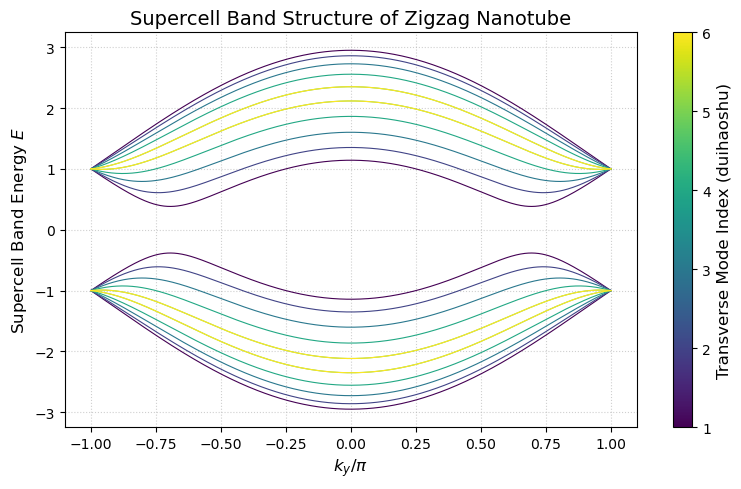

In [58]:

# ================= 1. 构造 k 空间 (保持你之前的设定) =================
ks1 = np.linspace(-1 * np.pi, 1 * np.pi, 605)
extra_points = np.array([-2 / (3 * np.pi), 2 / (3 * np.pi)])
ks1 = np.sort(np.concatenate((ks1, extra_points)))

# 定义动量空间的布洛赫哈密顿量
def Hk(k, H, T):
    # 注意：这里的 H 和 T 接下来都会是 4x4 的矩阵
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5))

# ================= 2. 设置色图 =================
cmap = cm.get_cmap('viridis')
# 假设 max_duihaoshu = m，根据你前面的设定，比如 m = 3
norm = colors.Normalize(vmin=1, vmax=max_duihaoshu)

# ================= 3. 遍历计算能带 =================
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Supercell Bands"):
    
    # 提取交替的格点在位矩阵和基础跃迁矩阵
    H_q_1 = mats["H_q_list"][0]  # 第1个格点 (2x2)
    H_q_2 = mats["H_q_list"][1]  # 第2个格点 (2x2)
    T_21 = mats["T_21"]          # 基础跃迁 (2x2)
    
    # 💥 核心修改 1：构造 4x4 的超胞在位哈密顿量 H_super
    H_super = np.block([
        [H_q_1,         T_21],
        [T_21.conj().T, H_q_2]
    ])

    # 💥 核心修改 2：构造 4x4 的超胞间跃迁矩阵 T_super (T_21 放在左下角)
    zero_2 = np.zeros((2, 2), dtype=complex)
    T_super = np.block([
       [zero_2, zero_2],
       [T_21,   zero_2]
    ])
 
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:
        # 把 4x4 的超胞矩阵喂给 Hk
        H_k = Hk(k, H_super, T_super)
        # 用 eigvalsh 算厄米矩阵本征值，直接返回实数
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前模式的能带 (现在每个 k 点会解出 4 条能带！)
    for i in range(energies1.shape[1]):
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 4. 设置坐标轴和出图 =================
plt.xlabel(r'$k_y/\pi$', fontsize=12)
plt.ylabel('Supercell Band Energy $E$', fontsize=12)
plt.title('Supercell Band Structure of Zigzag Nanotube', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Transverse Mode Index (duihaoshu)', fontsize=12)

plt.tight_layout()
plt.show()

开始并行计算，总共 1000 个能量点，启动 14 个线程...


Calculating Total Conductance: 100%|██████████| 1000/1000 [00:00<00:00, 2245.15it/s]


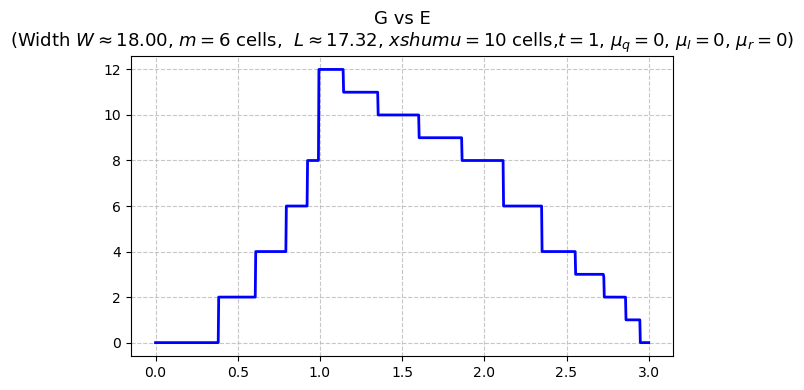

In [59]:
# G vs E xshumu定

E_vals_11 = np.linspace(0, 3, 1000)
eta = 1e-6

print(f"开始并行计算，总共 {len(E_vals_11)} 个能量点，启动 14 个线程...")

# 核心：使用 joblib 开启 14 个进程进行并行计算
# tqdm 用于在主进程中显示分配进度
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
    for E_val in tqdm(E_vals_11, desc="Calculating Total Conductance")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list_11 = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(6, 4))

plt.plot(E_vals_11, G_total_list_11 , color='b', linewidth=2)

W_val = m * a
L_val= xshumu* b
plt.title('G vs E'+ '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(0,1)

plt.show()